In [28]:
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader,Subset
import matplotlib.pyplot as plt

In [29]:
t = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(.5,.5,.5))])
trd = DataLoader(Subset(torchvision.datasets.CIFAR10('./data',True,download=True,transform=t),range(2000)),batch_size=64,shuffle=True)
ted = DataLoader(Subset(torchvision.datasets.CIFAR10('./data',False,download=True,transform=t),range(500)),batch_size=64)

Files already downloaded and verified
Files already downloaded and verified


In [30]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(4096,128), nn.ReLU(), nn.Linear(128,10)
        )
    def forward(self,x):
        return self.net(x)
    

In [31]:
def train(model,opt,crit,epochs=5):
    trl, tel, acl = [],[],[]
    for e in range(epochs):
        model.train()
        rl = 0
        for x,y in trd:
            opt.zero_grad()
            o = model(x)
            l = crit(o,y)
            l.backward()
            opt.step()
            rl += l.item()
        tl,c,n = 0,0,0
        with torch.no_grad():
            for x,y in ted:
                o = model(x)
                l = crit(o,y)
                tl += l.item()
                c += (o.argmax(1)==y).sum().item()
                n += len(y)
        trl.append(rl/len(trd))
        tel.append(tl/len(ted))
        acl.append(c/n)
        print(f'Epoch {e+1} | Train Loss: {rl/len(trd)} | Test Loss: {tl/len(ted)} | Accuracy: {c/n:.2f}')
    return trl,tel,acl

In [32]:
crit = nn.CrossEntropyLoss()
ma = CNN()
print('Adam')
tra, tla, aca = train(ma, optim.Adam(ma.parameters(),1e-3), crit)
ms = CNN()
print('SGD')
trs, tls, acs = train(ms, optim.SGD(ms.parameters(),0.01, momentum=0.9), crit)

Adam
Epoch 1 | Train Loss: 1.9352397099137306 | Test Loss: 1.8013956099748611 | Accuracy: 0.33
Epoch 2 | Train Loss: 1.587770078331232 | Test Loss: 1.7461910992860794 | Accuracy: 0.37
Epoch 3 | Train Loss: 1.3355236612260342 | Test Loss: 1.6345116794109344 | Accuracy: 0.42
Epoch 4 | Train Loss: 1.1476250980049372 | Test Loss: 1.6785140186548233 | Accuracy: 0.43
Epoch 5 | Train Loss: 0.9475681446492672 | Test Loss: 1.6986626982688904 | Accuracy: 0.44
SGD
Epoch 1 | Train Loss: 2.2235138937830925 | Test Loss: 2.0654118955135345 | Accuracy: 0.28
Epoch 2 | Train Loss: 1.948762085288763 | Test Loss: 1.896005541086197 | Accuracy: 0.32
Epoch 3 | Train Loss: 1.741180494427681 | Test Loss: 1.7925842702388763 | Accuracy: 0.36
Epoch 4 | Train Loss: 1.6196278296411037 | Test Loss: 1.6933783292770386 | Accuracy: 0.39
Epoch 5 | Train Loss: 1.5343124940991402 | Test Loss: 1.6880153864622116 | Accuracy: 0.40


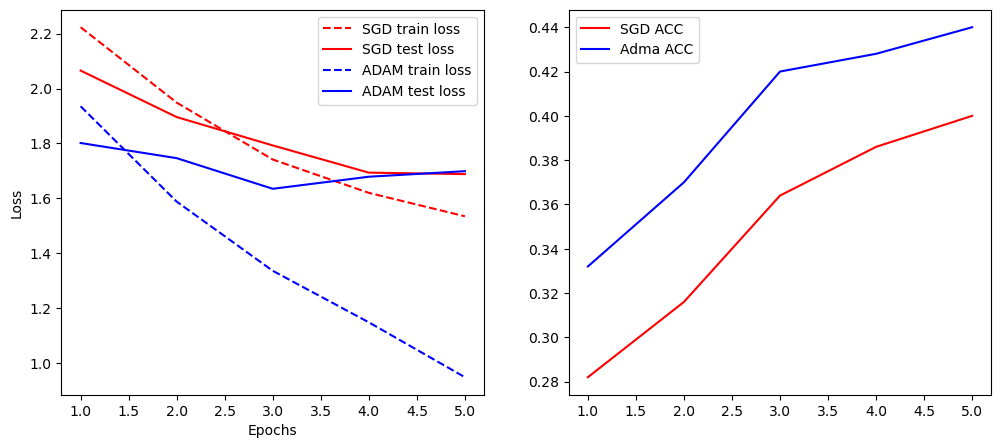

In [33]:
ep = range(1,6)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ep,trs,'r--',label='SGD train loss')
plt.plot(ep,tls,'r-',label='SGD test loss')
plt.plot(ep,tra,'b--',label='ADAM train loss')
plt.plot(ep,tla,'b-',label='ADAM test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(ep,acs,'r-',label='SGD ACC')
plt.plot(ep,aca,'b-',label='Adma ACC')
plt.legend()